#**TFM - Parte II: Analítica Avanzada e Inteligencia Artifical**

In [ ]:
# Importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Importamos dataset obtenido en la primera parte
df = pd.read_csv('df_procesado_empleados.csv')

In [ ]:
df.head()

,Referencia,perfil,genero,jornada,equipo,ubicacion,nivel_estudios,estado_civil,edad,antiguedad_empresa,grupo_profesional,salario_mensual,departamento,distancia_trabajo_km,promociones,satisfaccion,salario_anual,impacto_abandono
0,TRB-0000002,1,1,1,SEVILLA,1,1,CASADO,46,25,6,3617,DIRECCION,10,3,4,43404,8680.8
1,TRB-0000005,0,0,1,SEVILLA,1,4,CASADO,48,10,5,2562,RESPONSABLE DE AREA,14,2,2,30744,6148.8
2,TRB-0000007,1,0,1,ADMINISTRACION,1,4,CASADO,50,24,6,3605,DIRECCION,6,3,3,43260,8652.0
3,TRB-0000008,1,0,1,ORIENTE MEDIO,0,3,SOLTERO/A,50,24,6,3696,DIRECCION,8,3,3,44352,8870.4
4,TRB-0000009,1,0,1,MADRID,1,4,SOLTERO/A,48,24,6,3228,REFERENTES,9,3,3,38736,7747.2


Hemos analizado y dimensionado el problema desde la perspectiva del negocio; ahora, el siguiente paso es desarrollar un sistema automatizado que identifique los patrones ocultos en los datos y prediga qué empleados tienen mayor probabilidad de abandonar la empresa. De este modo, podremos intervenir de manera precisa y personalizada en cada caso.

#**1. Selección y preparación del modelo**

In [ ]:
# Importamos librerias necesarias
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import OneHotEncoder
import time

## Preprocesamiento de los datos

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 1. Selección de columnas numéricas relevantes
columnas_numericas = [
    'edad',
    'salario_mensual',
    'antiguedad_empresa',
    'distancia_trabajo_km',
    'promociones',
    'grupo_profesional',
    'satisfaccion'
]

# 2. Aplicamos MinMaxScaler
scaler = MinMaxScaler()
datos_escalados = scaler.fit_transform(df[columnas_numericas])

# Convertimos el resultado en un DataFrame con nombres adecuados
df_escalado = pd.DataFrame(datos_escalados, columns=[f"{col}_scaled" for col in columnas_numericas])

# Eliminamos las columnas originales numéricas para no duplicarlas
df_ajuste_sin_numericas = df.drop(columns=columnas_numericas).reset_index(drop=True)

# 3. Unimos el DataFrame escalado con el resto de columnas (categóricas u otras)
df_preprocesado = pd.concat([df_ajuste_sin_numericas, df_escalado], axis=1)

# 4. Preparar features (X) y target (y)
# Puedes agregar columnas categóricas aquí si quieres codificarlas después
columnas_features = [f"{col}_scaled" for col in columnas_numericas]
X = df_preprocesado[columnas_features]
y = df_preprocesado['perfil']

## Convertimos varibales categoricas a númericas, adecuadas para preparar nuestro modelo

In [ ]:
# Seleccionar columnas categóricas a codificar
columnas_categoricas = [
    'equipo',
    'estado_civil',
    'departamento',
]

# Aplicamos OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False)
categorical_encoded = encoder.fit_transform(df_preprocesado[columnas_categoricas])

# Creamos dataframe con nombres de columnas codificadas
columnas_codificadas = encoder.get_feature_names_out(columnas_categoricas)
df_categoricas = pd.DataFrame(categorical_encoded, columns=columnas_codificadas)

# Reseteamos índice para poder concatenar
df_categoricas.reset_index(drop=True, inplace=True)
X.reset_index(drop=True, inplace=True)

# Unimos features escaladas con las categóricas codificadas
X_final = pd.concat([X, df_categoricas], axis=1)


In [ ]:
X_final

,edad_scaled,salario_mensual_scaled,antiguedad_empresa_scaled,distancia_trabajo_km_scaled,promociones_scaled,grupo_profesional_scaled,satisfaccion_scaled,equipo_BARCELONA,equipo_CADIZ,equipo_EL SALVADOR,...,equipo_VALLADOLID,equipo_ZARAGOZA,estado_civil_DIVORCIADO/A LEGALMENTE,estado_civil_SOLTERO/A,departamento_COORDINADORA GENERAL,departamento_DIRECCION,departamento_LIMPIEZA,departamento_REFERENTES,departamento_RESPONSABLE DE AREA,departamento_TECNICAS
0,0.538462,0.793891,0.961538,0.473684,0.75,0.750,1.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.589744,0.555204,0.384615,0.684211,0.50,0.625,0.333333,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.641026,0.791176,0.923077,0.263158,0.75,0.750,0.666667,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.641026,0.811765,0.923077,0.368421,0.75,0.750,0.666667,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.589744,0.705882,0.923077,0.421053,0.75,0.750,0.666667,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,0.051282,0.433484,0.000000,0.578947,0.00,0.250,0.666667,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
207,0.102564,0.453846,0.000000,0.473684,0.00,0.250,0.666667,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
208,0.000000,0.430769,0.000000,0.684211,0.00,0.250,1.000000,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
209,0.128205,0.470136,0.000000,0.368421,0.00,0.375,0.666667,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


##Modelo de Regresión Logística

Justificación: Se ha elegido utilizar la regresión logística porque se adapta perfectamente a problemas de clasificación binaria como la rotación (abandono = 0, permanencia = 1). Este modelo ofrece una alta interpretabiliadad, permitiendo identificar qué factores influyen en la probabiliad de abandono, y proporciona una salida probabilistica que facilita priorizar acciones de retención. Además, es eficiente computacionalmente y ampliamente validado en contextos similares de RR.HH.

#**2. Entrenamiento inicial del modelo de regresión logística**


=== Evaluación del modelo de Regresión Logística ===
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        24
           1       0.81      0.89      0.85        19

    accuracy                           0.86        43
   macro avg       0.86      0.86      0.86        43
weighted avg       0.87      0.86      0.86        43


=== AUC-ROC Score ===
0.9451754385964912

Tiempo de entrenamiento: 0.07 segundos

=== Matriz de confusión ===


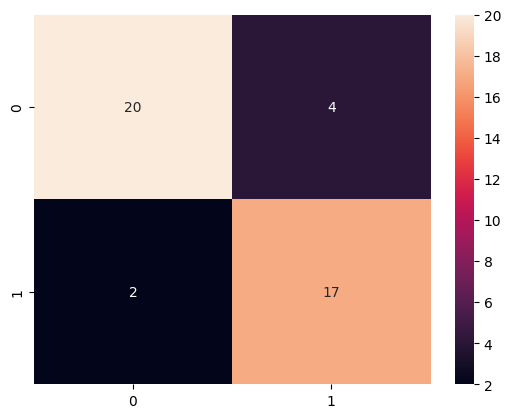

In [ ]:
# 1. División en entrenamiento y test (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)

# 2. Entrenar modelo de regresión logística
modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train, y_train)

# 3. Predicciones
y_pred = modelo_log.predict(X_test)
y_prob = modelo_log.predict_proba(X_test)[:, 1]

# 4. Evaluación del modelo
# Resultados en el Conjunto de Testing
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)

print("\n=== Evaluación del modelo de Regresión Logística ===")
print(classification_report(y_test, y_pred))

print("\n=== AUC-ROC Score ===")
print(roc_auc_score(y_test, y_prob))

start_time = time.time()               # Inicio del cronómetro
modelo_log.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"\nTiempo de entrenamiento: {training_time:.2f} segundos")

print("\n=== Matriz de confusión ===")

#2.1 Probamos otros modelos como Random Forest y XGBoost

Random Forest
Confusion Matrix:
 [[23  1]
 [ 0 19]]
Evaluación del modelo Random Forest:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        24
           1       0.95      1.00      0.97        19

    accuracy                           0.98        43
   macro avg       0.97      0.98      0.98        43
weighted avg       0.98      0.98      0.98        43

AUC-ROC: 0.9890350877192983

Tiempo de entrenamiento: 0.00 segundos


<Axes: >

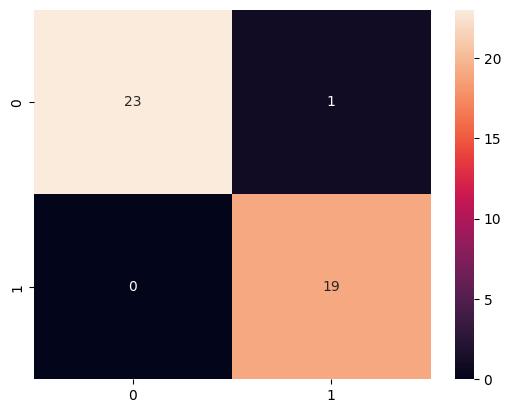

In [ ]:
# 1. RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("Evaluación del modelo Random Forest:\n", classification_report(y_test, rf_pred))
print("AUC-ROC:", roc_auc_score(y_test, rf_prob))

start_time = time.time()               # Inicio del cronómetro
modelo_log.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"\nTiempo de entrenamiento: {training_time:.2f} segundos")

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True)



 XGBoost
Confusion Matrix:
 [[22  2]
 [ 0 19]]
Evaluación del modelo XGBoost:
               precision    recall  f1-score   support

           0       1.00      0.92      0.96        24
           1       0.90      1.00      0.95        19

    accuracy                           0.95        43
   macro avg       0.95      0.96      0.95        43
weighted avg       0.96      0.95      0.95        43

AUC-ROC: 0.9868421052631579

Tiempo de entrenamiento: 0.04 segundos


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:46:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:46:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


<Axes: >

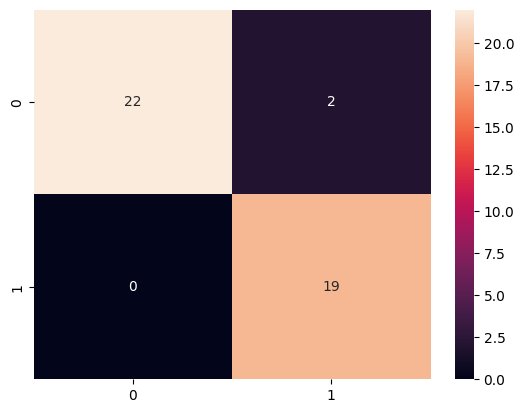

In [ ]:
# 2. XGBOOST
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("\n XGBoost")
print("Confusion Matrix:\n", confusion_matrix(y_test, xgb_pred))
print("Evaluación del modelo XGBoost:\n", classification_report(y_test, xgb_pred))
print("AUC-ROC:", roc_auc_score(y_test, xgb_prob))

start_time = time.time()               # Inicio del cronómetro
xgb_model.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"\nTiempo de entrenamiento: {training_time:.2f} segundos")

cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True)

#**3. Optimización del modelo**

#3.1 Ajustes de hiperparametros para el modelo de Regresión Logística

In [ ]:
# Ajuste de hiperparametros para el modelo de regresión logística
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Supongamos que ya tenemos los datos preparados
X_train, X_test, y_train, y_test

# Definimos un pipeline para escalar los datos y aplicar la regresión logística
pipeline = Pipeline([
    ('scaler', StandardScaler()),            # Escalado de variables numéricas
    ('log_reg', LogisticRegression(max_iter=1000))  # Modelo base
])

# Definimos la cuadrícula de hiperparámetros
param_grid = {
    'log_reg__C': [0.01, 0.1, 1, 10, 100],       # Regularización
    'log_reg__penalty': ['l1', 'l2'],            # Tipo de penalización
    'log_reg__solver': ['liblinear', 'saga']     # Solvers compatibles con l1 y l2
}

# Configuramos GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,                       # 5-fold cross-validation
    scoring='accuracy',         # Métrica principal (puedes usar 'f1', 'roc_auc', etc.)
    n_jobs=-1                   # Usa todos los núcleos disponibles
)

# Entrenamos la búsqueda
grid_search.fit(X_train, y_train)

# Resultados
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

print(f"Mejor accuracy en validación: {grid_search.best_score_:.4f}")


Mejores hiperparámetros encontrados:
{'log_reg__C': 0.01, 'log_reg__penalty': 'l2', 'log_reg__solver': 'saga'}
Mejor accuracy en validación: 0.7681


In [ ]:
# Entrenamiento del modelo con los mejores parametros encontrados
modelo_log = LogisticRegression(max_iter=1000, C=0.1, penalty='l2', solver='liblinear')
modelo_log.fit(X_train, y_train)

# Predicciones
log_pred = modelo_log.predict(X_test)
log_pred[:10]

array([1, 0, 0, 1, 0, 0, 0, 1, 1, 0])

0.813953488372093
Confusion Matrix:
 [[21  3]
 [ 5 14]]
Evaluación del modelo de Regresión Logística:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84        24
           1       0.82      0.74      0.78        19

    accuracy                           0.81        43
   macro avg       0.82      0.81      0.81        43
weighted avg       0.81      0.81      0.81        43



<Axes: >

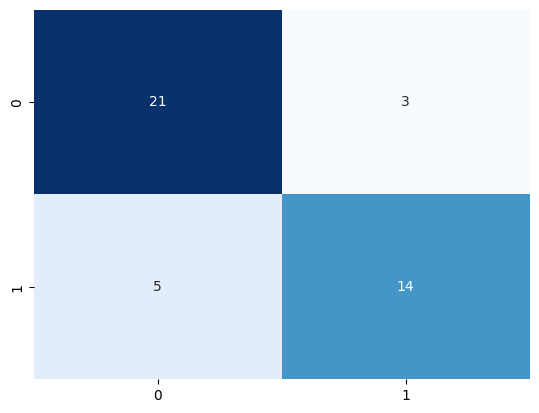

In [ ]:
# Evaluación del modelo de Regresión Logística
print(accuracy_score(y_test, log_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, log_pred))
print("Evaluación del modelo de Regresión Logística:\n", classification_report(y_test, log_pred))

cm = confusion_matrix(y_test, log_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

#3.2 Ajustes de hiperparametros para el modelo Random Forest

In [ ]:
# Ajuste de hiperparametros para el modelo de Random Forest
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Modelo
model = RandomForestClassifier(random_state=42)

# Espacio de hiperparametros
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Configuramos la búsqueda aleatoria
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Entrenamos la búsqueda
random_search.fit(X_train, y_train)

# Mejor combinación
print("Mejores hiperparametros encontrados:")
print(random_search.best_params_)

print("\nMejor puntuación f1_macro:")
print(random_search.best_score_)


Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores hiperparametros encontrados:
{'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}

Mejor puntuación f1_macro:
0.7988011554419978


In [ ]:
# Entrenamiento del modelo con los mejores parámetros encontrados
RF = RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    max_depth=10,
    random_state=42
)
RF.fit(X_train, y_train)

# Predicciones
RF_pred = RF.predict(X_test)
RF_pred[:10]
#RF_prob = RF.predict_proba(X_test)[:, 1]

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 0])

0.9302325581395349
Confusion Matrix:
 [[22  2]
 [ 1 18]]
Evaluación del modelo Random Forest:
               precision    recall  f1-score   support

           0       0.96      0.92      0.94        24
           1       0.90      0.95      0.92        19

    accuracy                           0.93        43
   macro avg       0.93      0.93      0.93        43
weighted avg       0.93      0.93      0.93        43



<Axes: >

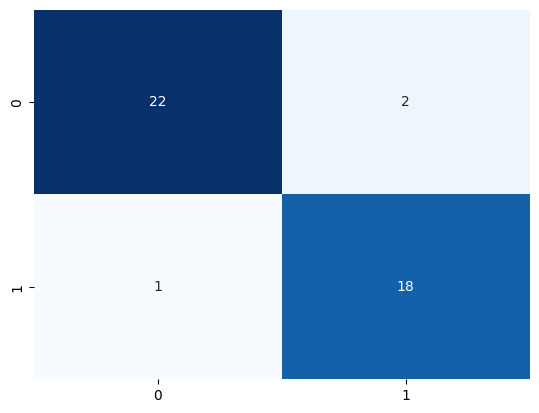

In [ ]:
# Evaluación del modelo RF
print(accuracy_score(y_test, RF_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, RF_pred))
print("Evaluación del modelo Random Forest:\n", classification_report(y_test, RF_pred))

cm = confusion_matrix(y_test, RF_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

#3.3 Ajuste de hiperparametros para el modelo XGBoost

In [ ]:
# 1. Definir el modelo base
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# 2. Espacio de hiperparámetros
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5]
}

# 3. Configurar RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,           # Número de combinaciones aleatorias a probar
    cv=5,                # Validación cruzada 5-fold
    scoring='f1_macro',  # Métrica de evaluación
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# 4. Entrenar búsqueda y medir tiempo
start_time = time.time()
random_search.fit(X_train, y_train)
end_time = time.time()
print(f"\nTiempo de búsqueda de hiperparámetros: {end_time - start_time:.2f} segundos")

# 5. Mostrar mejores hiperparámetros y score
print("Mejores hiperparámetros encontrados:")
print(random_search.best_params_)

print("\nMejor F1-macro en validación:")
print(random_search.best_score_)



Fitting 5 folds for each of 50 candidates, totalling 250 fits

Tiempo de búsqueda de hiperparámetros: 17.84 segundos
Mejores hiperparámetros encontrados:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 1.0}

Mejor F1-macro en validación:
0.8135837537732098


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:47:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:47:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Tiempo de entrenamiento: 0.08 segundos

=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        24
           1       0.90      1.00      0.95        19

    accuracy                           0.95        43
   macro avg       0.95      0.96      0.95        43
weighted avg       0.96      0.95      0.95        43


=== AUC-ROC ===
0.9978070175438597


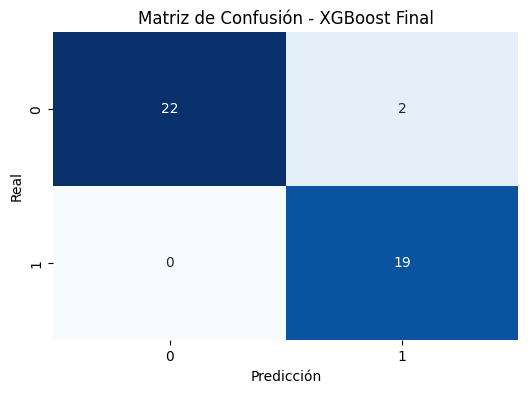

In [ ]:
# 1. Modelo final con los mejores hiperparámetros
# Reemplazamos los valores con los que obtuvimos de RandomizedSearchCV
best_params = {
    'n_estimators': 300,
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 1,
    'colsample_bytree': 1,
    'gamma': 0
}

xgb_final = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    **best_params
)

# 2. Entrenamiento y medición de tiempo
start_time = time.time()
xgb_final.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"\nTiempo de entrenamiento: {training_time:.2f} segundos")

# 3. Predicciones
y_pred = xgb_final.predict(X_test)
y_prob = xgb_final.predict_proba(X_test)[:, 1]  # Probabilidades para AUC-ROC

# 4. Evaluación del modelo
print("\n=== Reporte de Clasificación ===")
print(classification_report(y_test, y_pred))

print("\n=== AUC-ROC ===")
print(roc_auc_score(y_test, y_prob))

# 5. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusión - XGBoost Final")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


#**4. Evaluación y comparación de Modelos**


=== Tabla comparativa de métricas ===
                Modelo  Accuracy  Precision    Recall        F1   AUC-ROC
0  Regresión Logística  0.813953   0.823529  0.736842  0.777778  0.925439
1        Random Forest  0.930233   0.900000  0.947368  0.923077  0.989035
2              XGBoost  0.953488   0.904762  1.000000  0.950000  0.997807


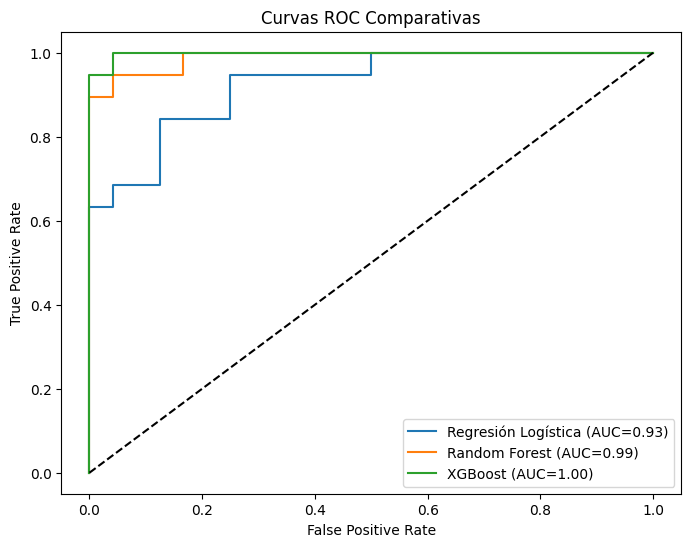

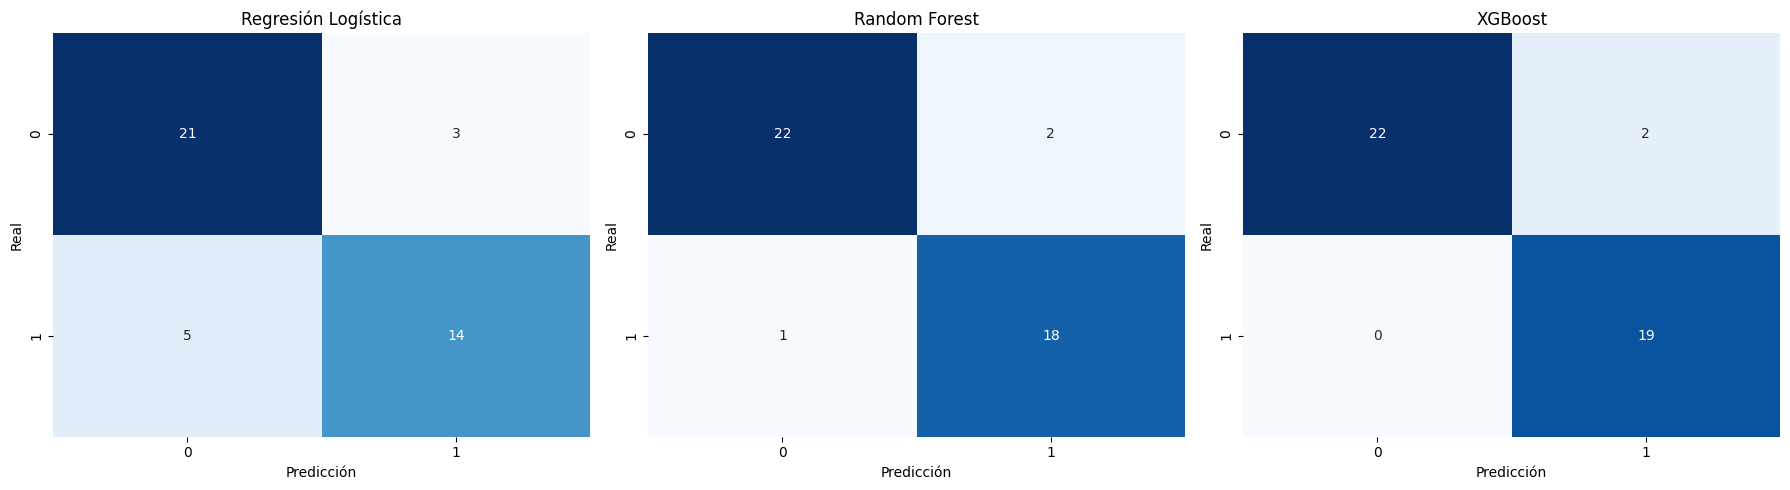

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# 1. Definir modelos finales ya entrenados
modelos = {
    'Regresión Logística': modelo_log,
    'Random Forest': RF,
    'XGBoost': xgb_final
}

# 2. Evaluación de métricas y creación de tabla comparativa
resultados = []

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]  # Probabilidad clase positiva

    report = classification_report(y_test, y_pred, output_dict=True)
    auc = roc_auc_score(y_test, y_prob)

    resultados.append({
        'Modelo': nombre,
        'Accuracy': report['accuracy'],
        'Precision': report['1']['precision'],
        'Recall': report['1']['recall'],
        'F1': report['1']['f1-score'],
        'AUC-ROC': auc
    })

df_resultados = pd.DataFrame(resultados)
print("\n=== Tabla comparativa de métricas ===")
print(df_resultados)

# 3. Curvas ROC comparativas
plt.figure(figsize=(8,6))
for nombre, modelo in modelos.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={roc_auc_score(y_test, y_prob):.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC Comparativas")
plt.legend()
plt.show()

# 4. Matrices de confusión comparativas
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, (nombre, modelo) in zip(axes, modelos.items()):
    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues', cbar=False)
    ax.set_title(nombre)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()


#Conclusiones:


Con base en los resultados obtenidos, XGBoost se posiciona como el modelo más adecuado para predecir la rotación laboral, logrando un AUC perfecto (1.00) y eliminando completamente los falsos negativos, lo que permite detectar todos los casos de abandono. Random Forest también ofrece un desempeño sobresaliente, con AUC de 0.99 y únicamente un falso negativo, constituyendo una alternativa robusta cuando se busca un equilibrio entre rendimiento y simplicidad. En cambio, la Regresión Logística, aunque presenta una buena capacidad predictiva (AUC=0.93), pierde precisión en la detección de abandonos, cometiendo más errores en la clase positiva. Por lo tanto, para maximizar la detección temprana de empleados en riesgo de abandonar la empresa, XGBoost es la mejor opción, mientras que Random Forest puede utilizarse como respaldo y la Regresión Logística como herramienta complementaria para interpretación de factores.



#**5. Interpretación del modelo**

PermutationExplainer explainer: 44it [00:10,  3.40s/it]


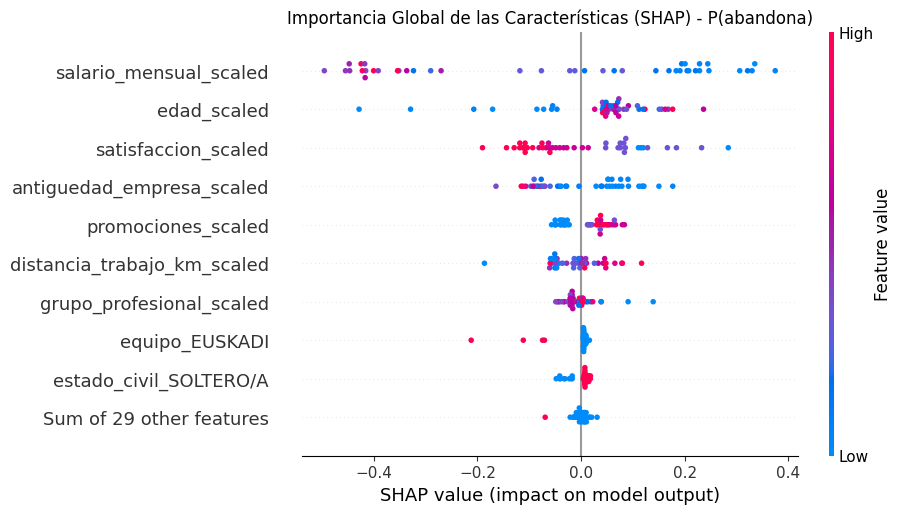

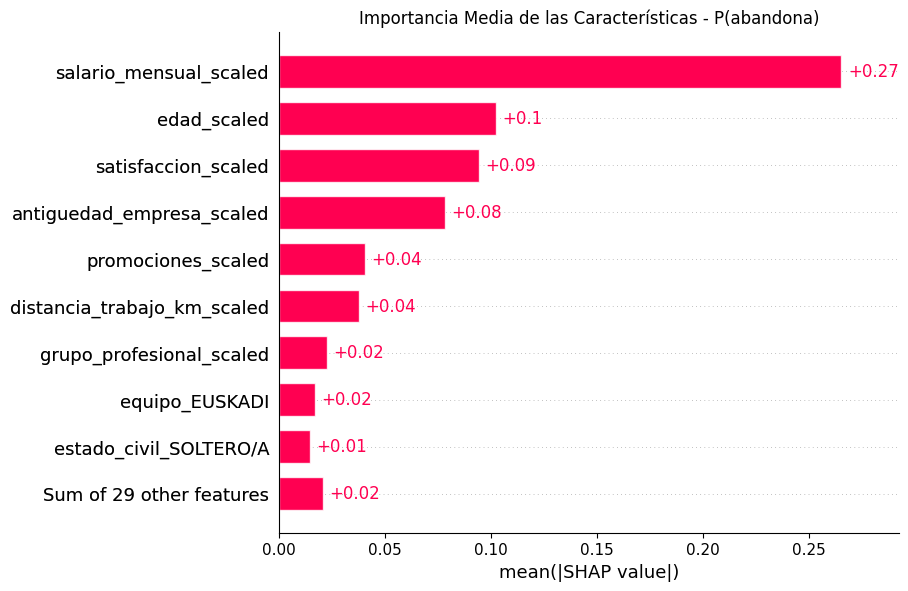

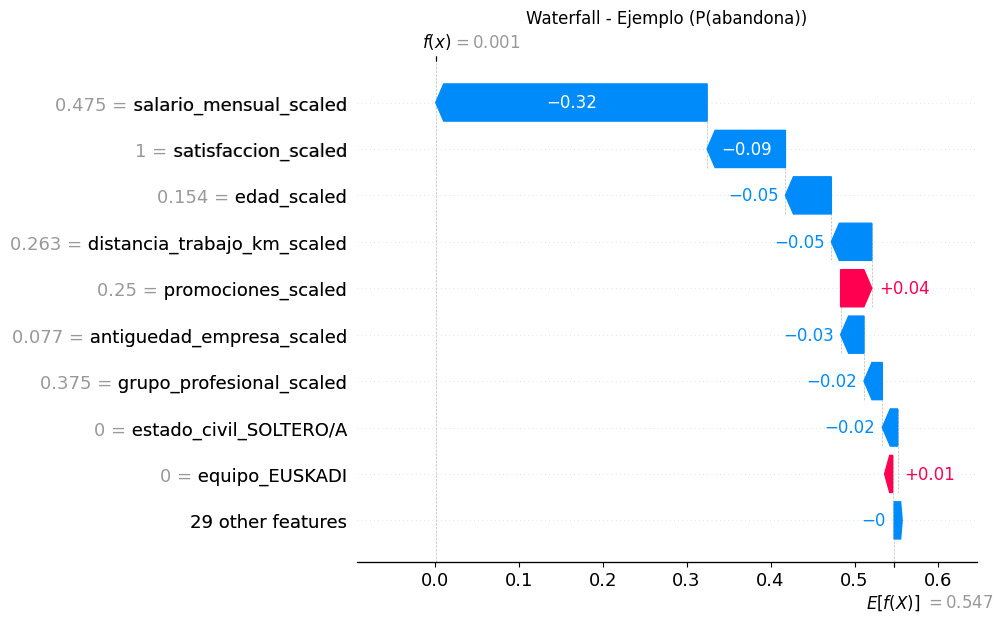

In [ ]:
import shap # SHAPE calcula las contribuciones de cada caracteristica a la predicción del modelo

# índice de la clase 'abandona' (label 0)
index_abandona = list(xgb_final.classes_).index(0) # xgb_final.classes_ busca la posición(índice) de la eiqueta 0, que en mi caso significa "abandona"

def prob_abandona_fn(X):
    return xgb_final.predict_proba(X)[:, index_abandona] # Nos devuelve la probabilidad predicha de que cada registro pertenezca a la clase "abandona"

explainer = shap.Explainer(prob_abandona_fn, X_train)   # explicador sobre la función P(abandona)
sv = explainer(X_test) # Calcula los valores SHAP para cada registro en X_test

# Plots que ahora explican P(abandona)
plt.title("Importancia Global de las Características (SHAP) - P(abandona)")
shap.plots.beeswarm(sv)
plt.title("Importancia Media de las Características - P(abandona)")
shap.plots.bar(sv)
plt.title("Waterfall - Ejemplo (P(abandona))")
shap.plots.waterfall(sv[0])

#Conclusiones:
El salario mensual escalado es la variable que más explica la predicción de abandono: salarios más altos reducen de forma consistente la probabilidad de irse. Edad, satisfacción y antigüedad aportan señal secundaria y con efectos menos uniformes, a menudo dependientes del contexto o interacciones. En casos individuales (waterfall) puede verse claramente cómo el salario resta riesgo mientras que unas pocas variables suman algo de probabilidad de abandono. En conjunto, el modelo sugiere priorizar el análisis salarial y la segmentación por roles antes de diseñar intervenciones. Hay que recordar que SHAP muestra asociación predictiva, no causalidad, por lo que cualquier acción debe validarse con análisis causal o pilotos.

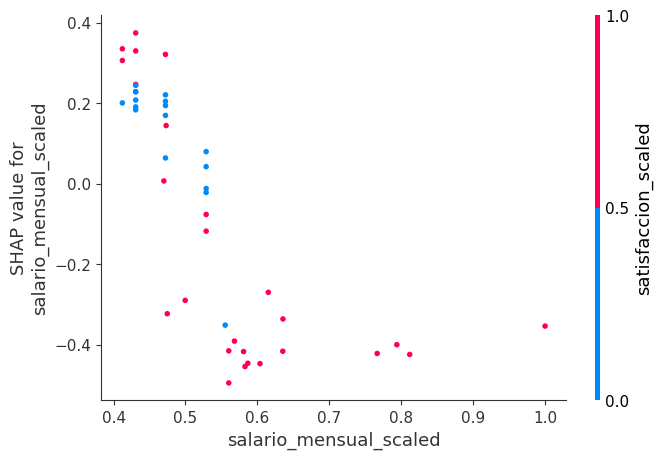

In [ ]:
# Relación entre  el valor de la feautre "salario_mensual_scaled" (eje X) y su contribución SHAP a la predicción (eje Y).
# Cada punto es un individuo; el color muestra la feature con la que "salario" más interractúa por defecto.
shap.dependence_plot("salario_mensual_scaled", sv.values, X_test)


*   Eje X = salario escalado
*   Eje Y = cuánto el salario contribuye a P(abandona): valores positivos = empujan a mayor probabilidad de abandono, negativos = reducen esa probabilidad.
*   Puntos en la parte superior: salario está aumentando P(abandona) para esos individuos; en la parte inferior: salario los protege (disminuye probabilidad). El color te dice con qué otra variable cambia esa relación.



En general: subir el salario (o tener salarios más altos) se asocia a menor probabilidad de abandono según el modelo.
Pero: hay un tramo de salarios bajos/medios (≈0.41–0.6), hay mucha dipersión con puntos que aumentan o disminuyen el riesgo donde el efecto del salario es variable y depende de la satisfacción u otras interacciones — allí conviene segmentar y analizar por subgrupos.
Ejemplo de interpretación no técnica: “El salario protege frente a la salida, especialmente cuando es suficientemente alto; sin embargo, entre los empleados peor pagados no todos se comportan igual: algunos, aun estando satisfechos, siguen en riesgo por su nivel salarial o por factores asociados.”

Propuesta de mejoras:

*   Hacer dependence plots separados o análsis por subgrupos clave (grupo_profesional, tipo de contrato, departamento,etc) para ver si la curva cambia por rol.



In [ ]:
# Asegurarnos de que índices coincidan
df = df.reset_index(drop=True)
X_final = X_final.reset_index(drop=True)
y = y.reset_index(drop=True)

# 1. Probabilidades de abandono para TODO el dataset
prob_abandono_todos = xgb_final.predict_proba(X_final)[:, 0]  # clase 0 = abandono

# 2. Crear DataFrame con resultados
resultados = X_final.copy()
resultados['perfil_activo'] = y  # etiqueta original
resultados['prob_abandono'] = prob_abandono_todos
resultados['Referencia'] = df['Referencia']  # ya coincide

# 3. Filtrar solo personas que permanecen (perfil_activo == 1)
casos_permanecen = resultados[resultados['perfil_activo'] == 1]

# 4. Crear DataFrame 'casos_en_riesgo' con las columnas deseadas
casos_en_riesgo = casos_permanecen[['Referencia', 'prob_abandono', 'perfil_activo']]

# 5. Mostrar el top 10 con referencia incluida
casos_en_riesgo[['Referencia', 'prob_abandono', 'perfil_activo']]

,Referencia,prob_abandono,perfil_activo
0,TRB-0000002,0.003458,1
2,TRB-0000007,0.002170,1
3,TRB-0000008,0.012615,1
4,TRB-0000009,0.008244,1
5,TRB-0000010,0.007375,1
...,...,...,...
206,TRB-0000243,0.021200,1
207,TRB-0000246,0.029211,1
208,TRB-0000247,0.264005,1
209,TRB-0000248,0.068995,1


In [ ]:
# Asegurar mismo tipo en la clave
df['Referencia'] = df['Referencia'].astype(str)
casos_en_riesgo['Referencia'] = casos_en_riesgo['Referencia'].astype(str)

# Si hay duplicados en casos_en_riesgo, agregarlos (media por Referencia)
if casos_en_riesgo['Referencia'].duplicated().any():
    casos_agg = (casos_en_riesgo
                 .groupby('Referencia', as_index=False)
                 .agg({'prob_abandono': 'mean'}))
else:
    casos_agg = casos_en_riesgo[['Referencia', 'prob_abandono']].copy()

# Hacer el merge left para conservar todas las filas de df y añadir la columna scoring_abandono
df_con_scores = df.merge(casos_agg, on='Referencia', how='left').rename(columns={'prob_abandono': 'scoring_abandono'})

# Opcional: si quieres dejar NaN = 0 (no recomendado sin criterio), descomenta:
df_con_scores['scoring_abandono'] = df_con_scores['scoring_abandono'].fillna(0)

# Comprobaciones rápidas
print("Filas totales df original:", len(df))
print("Filas con scoring no nulo:", df_con_scores['scoring_abandono'].notna().sum())

# Mostrar top 10 de los que permanecen ordenados por riesgo si existe la columna 'perfil_activo'
if 'perfil_activo' in df_con_scores.columns:
    display(df_con_scores[df_con_scores['perfil_activo'] == 1].sort_values('scoring_abandono', ascending=False).head(10))
else:
    display(df_con_scores.sort_values('scoring_abandono', ascending=False).head(10))

Filas totales df original: 211
Filas con scoring no nulo: 211


/tmp/ipython-input-1632523455.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  casos_en_riesgo['Referencia'] = casos_en_riesgo['Referencia'].astype(str)


,Referencia,perfil,genero,jornada,equipo,ubicacion,nivel_estudios,estado_civil,edad,antiguedad_empresa,grupo_profesional,salario_mensual,departamento,distancia_trabajo_km,promociones,satisfaccion,salario_anual,impacto_abandono,scoring_abandono
201,TRB-0000235,1,1,1,SEVILLA,1,2,SOLTERO/A,32,0,3,2195,TECNICAS,14,0,2,26340,5268.0,0.386467
198,TRB-0000225,1,0,1,PALMA DE MALLORCA,1,5,SOLTERO/A,47,2,2,2012,TECNICAS,19,0,3,24144,4828.8,0.367273
169,TRB-0000192,1,1,1,EUSKADI,1,4,SOLTERO/A,36,3,3,2185,TECNICAS,19,2,3,26220,5244.0,0.322318
208,TRB-0000247,1,0,1,BARCELONA,1,3,SOLTERO/A,25,0,2,2012,TECNICAS,14,0,4,24144,4828.8,0.264005
202,TRB-0000236,1,0,1,EL SALVADOR,0,4,SOLTERO/A,29,0,2,2012,TECNICAS,20,0,4,24144,4828.8,0.212522
163,TRB-0000184,1,0,1,EUSKADI,1,4,SOLTERO/A,30,0,3,2195,TECNICAS,4,0,1,26340,5268.0,0.208597
71,TRB-0000084,1,0,1,SEVILLA,1,4,SOLTERO/A,47,6,6,2916,REFERENTES,20,3,3,34992,6998.4,0.205379
189,TRB-0000216,1,0,1,ORIENTE MEDIO,0,3,SOLTERO/A,26,2,3,2195,TECNICAS,9,1,3,26340,5268.0,0.190397
186,TRB-0000212,1,0,1,BARCELONA,1,3,SOLTERO/A,32,2,4,2445,TECNICAS,12,0,2,29340,5868.0,0.172938
197,TRB-0000224,1,0,1,PAMPLONA,1,3,SOLTERO/A,30,2,3,2187,TECNICAS,18,2,2,26244,5248.8,0.161928


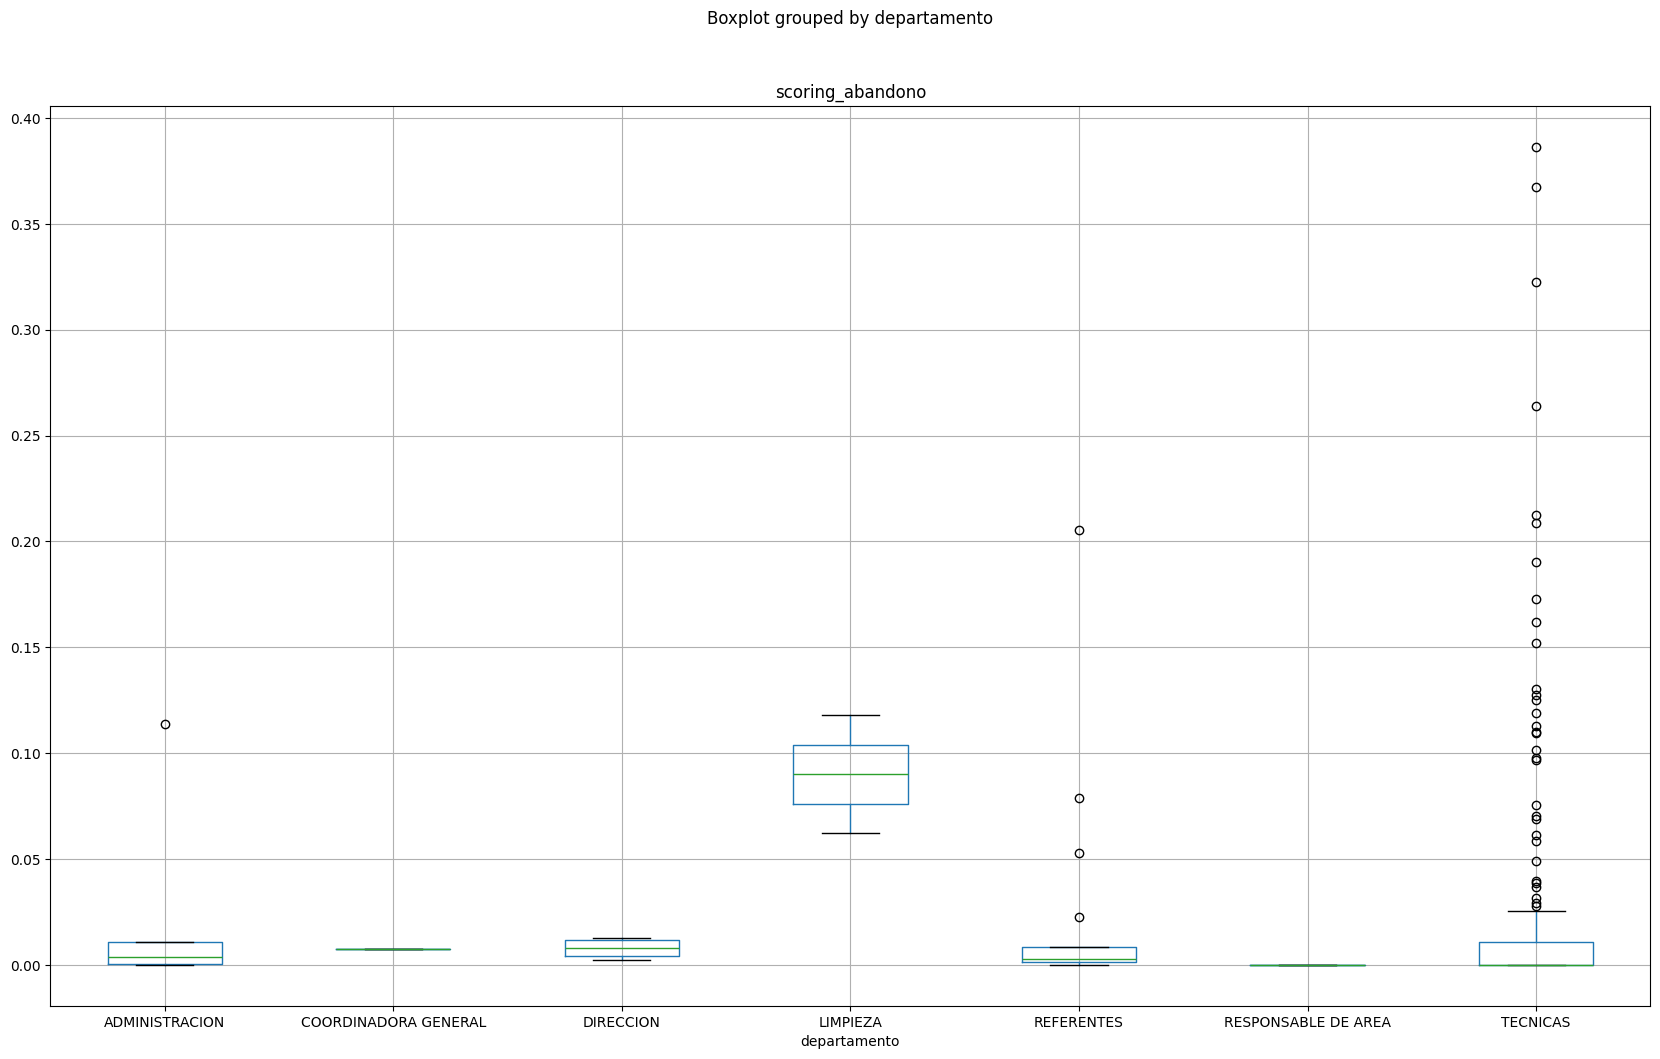

In [ ]:
df_con_scores.boxplot(column='scoring_abandono', by='departamento', figsize = (20,12));

In [ ]:
# descargar dataframe en excel
# from google.colab import files
# df_con_scores.to_excel('df_con_scores.xlsx', index=False)
# files.download('df_con_scores.xlsx')
